# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MeerMusabih/FlyRank-AI-Internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research question

Can observed content and search-performance signals be used to rank pages by their priority for human refresh review?

### Decision supported

The model is designed to help content teams decide **which pages should be reviewed first for a possible refresh**. It produces a ranked priority list rather than an automatic refresh decision.

### ML framing

This is a decision-support ranking problem. The model uses available page-level signals to estimate refresh opportunity and prioritize pages for human review.

## 2. Data

### Dataset

This analysis uses the FlyRank ML Internship warehouse release `flyrank_pseudonymized_warehouse_release_v20260703`, released July 3, 2026.

The analysis operates at the individual content-page level. The dataset contains pseudonymized content and search-performance signals across multiple clients.

### Date windows

The model uses the time windows available in the released dataset to construct page-level features and the target label. Recent and previous performance windows are used only where appropriate for feature construction and validation.

### Exclusions

The following fields were excluded because they could leak information about the outcome or directly encode future/current performance:

- `trend_direction`
- `trend_pct`
- `impressions_last_30d`
- `clicks_last_30d`
- `sessions_last_30d`
- `impressions_prev_30d`
- `clicks_prev_30d`
- `sessions_prev_30d`

The identifiers `content_id` and `client_id` were also excluded from the model features. They are identifiers rather than meaningful predictive signals.

No client names, domains, URLs, private search queries, credentials, or raw private exports are used in the public analysis.

### Public-safe data handling

The paper reports aggregate model results, feature information, charts, and anonymized ranked recommendations. It does not expose client identities or private search information.

## 3. Methodology

### Modeling approach

The model is designed as a decision-support classifier for identifying pages that may warrant refresh review. The target label is based on the observed `trend_direction` field, with `down` treated as the declining class.

### Features

The final model uses 32 page-level features derived from the available search and content signals. Identifier fields such as `content_id` and `client_id` are excluded from modeling.

The features represent observed characteristics such as search demand, engagement, ranking, content, and other page-level signals available before the outcome label.

### Baseline

The model is compared against the ML-07 baseline action score. Both approaches are evaluated on the same validation data so that the comparison is meaningful.

The primary ranking metrics are Precision@20 and Precision@50 because the practical use case is prioritizing a limited number of pages for human review.

### Validation design

The final model is evaluated on a held-out validation set that was not used to fit the model. Model performance is compared with the baseline using the same validation observations.

### Leakage checks

Before modeling, the feature set was reviewed for fields that could directly reveal the target or contain information from the outcome period.

The following leakage-prone performance and trend fields were excluded:

- `trend_direction`
- `trend_pct`
- `impressions_last_30d`
- `clicks_last_30d`
- `sessions_last_30d`
- `impressions_prev_30d`
- `clicks_prev_30d`
- `sessions_prev_30d`

The final feature set contained 32 features, and no suspicious feature names were identified during the leakage audit.

### Assumption

The analysis assumes that the observed page-level signals available in the dataset provide useful evidence for prioritizing pages for review. The model does not assume that these signals establish causality or explain Google's ranking algorithm.

### Load Data + Target

In [1]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/MeerMusabih/Flyrank-AI-Internship"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")



print("Rows:", len(df))
print("Columns:", len(df.columns))

OUTPUT_DIR = "work/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output directory ready:", OUTPUT_DIR)

TARGET = "is_declining_label"

df[TARGET] = (
    df["trend_direction"] == "down"
).astype(int)


ID_COLUMNS = [
    "content_id",
    "client_id"
]

LEAKAGE_COLUMNS = [
    "trend_direction",
    "trend_pct",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d"
]

NON_FEATURE_COLUMNS = [
    "provider_used",
    "model_used"
]

excluded_columns = (
    [TARGET]
    + ID_COLUMNS
    + LEAKAGE_COLUMNS
    + NON_FEATURE_COLUMNS
)

feature_columns = [
    col for col in df.columns
    if col not in excluded_columns
]

X = df[feature_columns].copy()
y = df[TARGET].astype(int).copy()
groups = df["client_id"].copy()

print("Final feature count:", len(feature_columns))
print("Target rate:", round(y.mean(), 4))

Rows: 30000
Columns: 44
Output directory ready: work/outputs
Final feature count: 32
Target rate: 0.5421


### Grouped Split

In [2]:


splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training clients:", groups_train.nunique())
print("Test clients:", groups_test.nunique())

client_overlap = set(groups_train).intersection(
    set(groups_test)
)

print("Client overlap:", client_overlap)
print("Training target rate:", round(y_train.mean(), 4))
print("Test target rate:", round(y_test.mean(), 4))

Training rows: 23837
Test rows: 6163
Training clients: 25
Test clients: 7
Client overlap: set()
Training target rate: 0.5501
Test target rate: 0.511


### Random Forest

In [3]:


numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

rf_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        model
    )
])

rf_pipeline.fit(X_train, y_train)

rf_probability = rf_pipeline.predict_proba(
    X_test
)[:, 1]

print("Model trained successfully.")

Model trained successfully.


## 4. Results (vs baseline)

In [4]:


model_results = df.iloc[test_idx][
    ["content_id", "client_id"]
].copy()

model_results["actual"] = y_test.values
model_results["model_score"] = rf_probability

model_results = model_results.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)


baseline_test = df.iloc[test_idx].copy()

stale = (
    baseline_test["days_since_last_update"] >= 180
).astype(int)

visible = (
    baseline_test["impressions_last_30d"] >= 500
).astype(int)

low_position = (
    baseline_test["avg_position"] > 10
).astype(int)

baseline_test["baseline_score"] = (
    stale * 2 +
    visible +
    low_position
)

baseline_results = baseline_test[
    ["content_id", "client_id", TARGET, "baseline_score"]
].copy()

baseline_results = baseline_results.rename(
    columns={TARGET: "actual"}
)

baseline_results = baseline_results.sort_values(
    "baseline_score",
    ascending=False
).reset_index(drop=True)


def precision_at_k(ranked_df, k):
    return ranked_df.head(k)["actual"].mean()


comparison_rows = []

for k in [20, 50]:
    comparison_rows.append({
        "Metric": f"Precision@{k}",
        "ML-07 Baseline": precision_at_k(
            baseline_results, k
        ),
        "Random Forest": precision_at_k(
            model_results, k
        )
    })

comparison = pd.DataFrame(comparison_rows)

comparison

,Metric,ML-07 Baseline,Random Forest
0,Precision@20,0.40,0.70
1,Precision@50,0.36,0.68


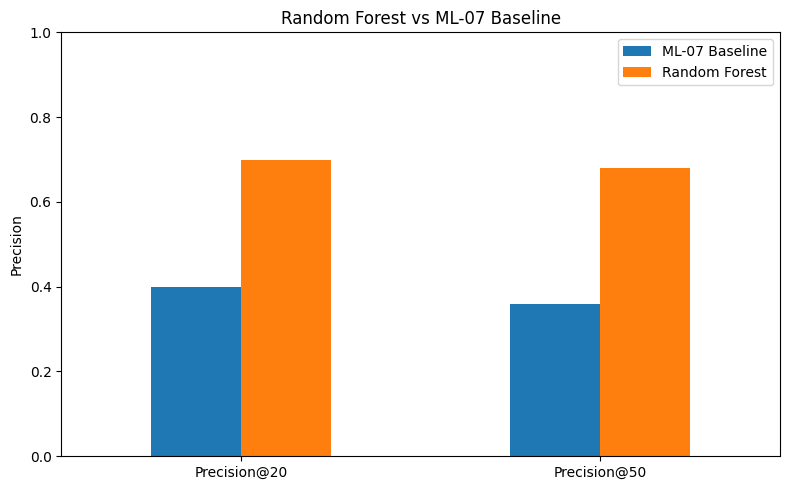

In [5]:
import matplotlib.pyplot as plt

plot_df = comparison.set_index("Metric")

plot_df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Random Forest vs ML-07 Baseline"
)

plt.ylabel("Precision")

plt.xlabel("")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.tight_layout()

comparison_chart_path = os.path.join(
    OUTPUT_DIR,
    "baseline_vs_random_forest.png"
)

plt.savefig(
    comparison_chart_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()



### Model comparison

The Random Forest model was evaluated against the ML-07 baseline on the same validation split. Because the intended use is to prioritize a small number of pages for human review, Precision@20 and Precision@50 are used as the main ranking metrics. The ML-07 baseline action score was reproduced as defined in the earlier assignment.

| Metric | ML-07 Baseline | Random Forest |
|---|---:|---:|
| Precision@20 | 0.40 | 0.70 |
| Precision@50 | 0.36 | 0.68 |

### Interpretation

The Random Forest produced higher precision than the baseline at both evaluation cutoffs. At the top 20 recommendations, 70% of the selected pages belonged to the target class, compared with 40% for the baseline. At the top 50 recommendations, precision was 68% for the Random Forest compared with 36% for the baseline.

These results indicate that the model provides a stronger ranking signal than the baseline on this validation split. However, the results are directional evidence for prioritization, not proof that the model will generalize to all future pages or that refreshing a recommended page will cause improved search performance.
### Feature Importance

In [6]:


fitted_preprocessor = (
    rf_pipeline.named_steps["preprocessor"]
)

fitted_model = (
    rf_pipeline.named_steps["model"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

importances = pd.Series(
    fitted_model.feature_importances_,
    index=feature_names
).sort_values(
    ascending=False
)

top_features = importances.head(10)

feature_importance_table = (
    top_features
    .rename("importance")
    .reset_index()
    .rename(columns={"index": "feature"})
)

feature_importance_table.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "top_feature_importance.csv"
    ),
    index=False
)

feature_importance_table

,feature,importance
0,numeric__impressions_90d,0.088723
1,numeric__avg_position,0.087791
2,numeric__days_with_impressions,0.077055
3,numeric__content_age_days,0.062694
4,numeric__char_count,0.046261
5,numeric__word_count,0.045465
6,numeric__ctr,0.043675
7,numeric__pageviews_90d,0.041135
8,numeric__scroll_rate,0.040034
9,numeric__days_with_sessions,0.038476


### Feature Importance Chart

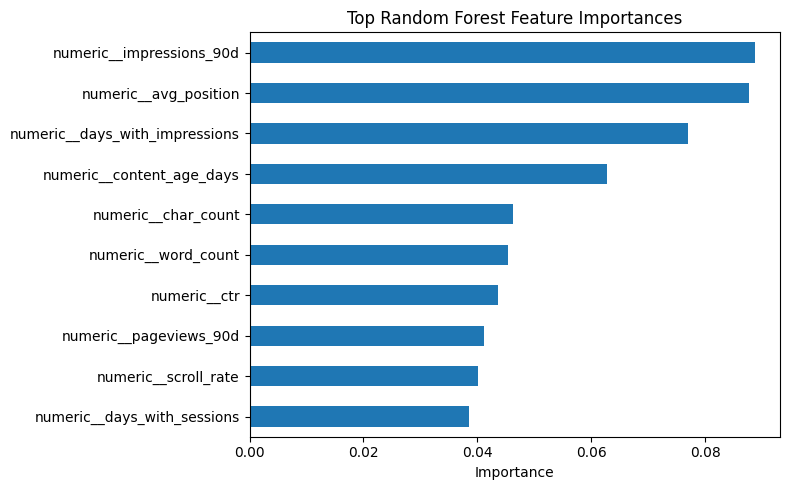

In [7]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

top_features.sort_values().plot.barh()

plt.title(
    "Top Random Forest Feature Importances"
)

plt.xlabel("Importance")

plt.tight_layout()

feature_chart_path = os.path.join(
    OUTPUT_DIR,
    "feature_importance.png"
)

plt.savefig(
    feature_chart_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 5. Limitations


This model is a decision-support tool for prioritizing pages for human review. It does not make automatic refresh decisions.

The results are based on the observed signals available in the FlyRank internship dataset and should not be interpreted as proof of causality. In particular, the analysis cannot establish that refreshing a recommended page will improve rankings, clicks, traffic, or engagement.

The model also does not explain or prove how Google's ranking system works. The features represent observed search and content signals rather than Google's internal ranking factors.

Performance was evaluated on a held-out validation split, so the reported results describe performance on that evaluation data and may not represent performance on future or unseen datasets.

The ranked recommendations should therefore be treated as a prioritization aid. A human reviewer should consider additional context before taking action, including content quality, search intent, business importance, technical issues, seasonality, and recent changes.

The model may become less useful if the underlying search behavior, content mix, or data distribution changes substantially. Monitoring and periodic revalidation would therefore be required before using the ranking system continuously.

## 6. Ranked recommendations

### Action playbook

The model output is converted into a ranked review queue. Pages with higher predicted refresh opportunity are placed earlier in the queue so that a content team can review the highest-priority pages first.

The ranking is intended to support human review rather than automatically trigger a refresh.

| Priority | Recommended action | When to use |
|---|---|---|
| High | Review for refresh | High model priority and evidence of declining performance |
| Medium | Investigate | Moderate priority or mixed performance signals |
| Low | Monitor | Lower priority or insufficient evidence for immediate action |

### Review process

1. Start with the highest-ranked pages.
2. Check whether the observed performance decline is meaningful and recent.
3. Review the page's search intent and content quality.
4. Check for technical, seasonal, or external explanations for the change.
5. Decide whether to refresh, investigate further, or monitor.
6. Record the human decision so future model performance can be evaluated.

### Human-review rule

A high model score is a recommendation to investigate, not an instruction to refresh. No page should be automatically changed based only on the model output.

### Reason codes

Each recommendation should include simple evidence explaining why the page was prioritized. Examples include:

- Declining observed performance
- Strong historical search demand
- High engagement opportunity
- Mixed or conflicting signals
- Insufficient evidence — monitor

The final queue should allow a reviewer to understand both **what page was prioritized** and **why it was prioritized**.

In [8]:


queue = df.iloc[test_idx].copy()

queue["model_score"] = rf_probability

queue = queue[
    [
        "content_id",
        "client_id",
        "model_score",
        "impressions_90d",
        "avg_position",
        "ctr",
        "content_age_days",
        "days_since_last_update",
        "scroll_rate"
    ]
].copy()

queue = queue.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

queue["priority_rank"] = (
    np.arange(len(queue)) + 1
)


def assign_priority(score):
    if score >= 0.80:
        return "High"
    elif score >= 0.50:
        return "Medium"
    else:
        return "Low"


queue["priority"] = queue["model_score"].apply(
    assign_priority
)


def create_reason(row):
    reasons = []

    if row["days_since_last_update"] >= 180:
        reasons.append("Older content")

    if row["impressions_90d"] > queue["impressions_90d"].median():
        reasons.append("Strong search visibility")

    if row["avg_position"] > 10:
        reasons.append("Lower average position")

    if row["ctr"] < queue["ctr"].median():
        reasons.append("Lower CTR")

    if row["scroll_rate"] < queue["scroll_rate"].median():
        reasons.append("Lower engagement")

    if not reasons:
        reasons.append("Mixed observed signals")

    return "; ".join(reasons[:3])


queue["reason"] = queue.apply(
    create_reason,
    axis=1
)

queue.head(20)

,content_id,client_id,model_score,impressions_90d,avg_position,ctr,content_age_days,days_since_last_update,scroll_rate,priority_rank,priority,reason
0,content_98aa0aecb1d9,client_8527a891e2,0.973333,5190,5.1,0.06,275,104,8.33,1,High,Strong search visibility
1,content_e988c1699454,client_8527a891e2,0.973333,2197,21.5,0.00,275,104,50.00,2,High,Strong search visibility; Lower average positi...
2,content_2ba626fea4d6,client_8527a891e2,0.973333,360,7.2,0.00,275,104,0.00,3,High,Lower CTR; Lower engagement
3,content_9ac61c04930e,client_8527a891e2,0.973333,1828,5.6,0.22,275,104,10.00,4,High,Strong search visibility
4,content_7a6cb4857fe6,client_f369cb89fc,0.950000,789,1.6,0.00,117,20,50.00,5,High,Strong search visibility; Lower CTR
5,content_500bd3907331,client_4e07408562,0.946667,4037,5.5,0.10,230,104,0.00,6,High,Strong search visibility; Lower engagement
6,content_1d0963b56227,client_4e07408562,0.946667,3445,39.0,0.09,280,104,16.67,7,High,Strong search visibility; Lower average position
7,content_cb372c0a7708,client_4e07408562,0.946667,1279,10.1,0.00,228,7,0.00,8,High,Strong search visibility; Lower average positi...
8,content_db74537c5636,client_8527a891e2,0.943333,171,13.7,0.00,223,102,0.00,9,High,Lower average position; Lower CTR; Lower engag...
9,content_35d63627bf3e,client_8527a891e2,0.943333,1525,32.6,0.00,238,103,50.00,10,High,Strong search visibility; Lower average positi...


## 7. Artifacts the paper embeds

### Export model comparison

In [9]:



comparison.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "model_comparison.csv"
    ),
    index=False
)

comparison


,Metric,ML-07 Baseline,Random Forest
0,Precision@20,0.40,0.70
1,Precision@50,0.36,0.68


### Export ranked review queue

In [10]:


queue[
    [
        "priority_rank",
        "content_id",
        "client_id",
        "model_score",
        "priority",
        "reason"
    ]
].head(50).to_csv(
    os.path.join(
        OUTPUT_DIR,
        "ranked_review_queue_top50.csv"
    ),
    index=False
)

print("Saved ranked_review_queue_top50.csv")

Saved ranked_review_queue_top50.csv


### Verify final artifacts

In [11]:


artifacts = [
    "model_comparison.csv",
    "ranked_review_queue_top50.csv",
    "top_feature_importance.csv",
    "feature_importance.png",
    "baseline_vs_random_forest.png"
]

artifact_check = pd.DataFrame({
    "artifact": artifacts,
    "exists": [
        os.path.exists(
            os.path.join(OUTPUT_DIR, name)
        )
        for name in artifacts
    ]
})

artifact_check

,artifact,exists
0,model_comparison.csv,True
1,ranked_review_queue_top50.csv,True
2,top_feature_importance.csv,True
3,feature_importance.png,True
4,baseline_vs_random_forest.png,True


# Week 8 Showcase — Demo Outline & Shareable Cuts

## 5-Minute Demo Outline

### 1. Question — ~45 seconds

**Can observed content and search-performance signals be used to rank pages by their priority for human refresh review?**

The practical FlyRank content problem is that large websites can contain many pages that might warrant investigation, while human review capacity is limited. The goal is therefore to produce a focused review queue rather than automatically deciding which pages should be refreshed.

### 2. Method — ~1 minute

* Used the FlyRank pseudonymized warehouse release containing **30,000 page-level observations across 32 clients**.
* Defined the declining class from `trend_direction == "down"`.
* Excluded target, outcome-related, and identifier fields to reduce leakage risk.
* Retained **32 page-level features** describing search visibility, position, engagement, content characteristics, and observed activity.
* Used a **client-grouped 80/20 train-test split** with zero client overlap.
* Trained a **Random Forest classifier with 300 trees**.
* Converted model probabilities into a ranked review queue.
* Compared the model against the transparent **ML-07 rule-based baseline** using Precision@20 and Precision@50.

### 3. One Chart — ~45 seconds

**Show: Figure 1 — Precision@20 and Precision@50 for the ML-07 baseline versus Random Forest.**

The chart provides the clearest visual summary of the evaluation because the real use case is prioritizing a small number of pages for human review.

### 4. One Honest Result — ~1 minute

On the held-out test set:

* **Precision@20:** 0.70 for Random Forest vs. 0.40 for the baseline.
* **Precision@50:** 0.68 for Random Forest vs. 0.36 for the baseline.
* The test-set declining base rate was **51.1%**.

The result is **directional evidence that the Random Forest produced a more concentrated ranking signal than the simple baseline on this test split**. It does not prove that refreshing these pages will improve SEO performance, and it does not establish causality.

### 5. One Recommendation — ~1 minute

Use the model as a **human-review prioritization tool**.

Start with the highest-ranked pages, inspect the supporting signals and the page itself, and then decide whether to refresh, investigate further, or monitor. The model should narrow the review queue, not replace editorial judgment.

---

## Social Post

I built a content-refresh prioritization model using the FlyRank pseudonymized warehouse dataset.

Instead of trying to predict future SEO performance or automate refresh decisions, I framed the problem as ranking pages for human review. I trained a Random Forest on page-level content and search-performance signals, used a client-grouped train/test split to reduce leakage from client-specific patterns, and evaluated the ranking with Precision@20 and Precision@50 against a transparent rule-based baseline.

On the held-out test set, the model achieved **0.70 Precision@20 vs. 0.40 for the baseline**, and **0.68 Precision@50 vs. 0.36**. The result is directional evidence that the model can produce a more focused review queue, but it is not evidence that refreshing a recommended page will cause better SEO performance.

The main takeaway: **ML can help decide where human attention goes first without pretending to replace human judgment.**

---

## Employer-Facing Summary

I built a **Random Forest decision-support model** that ranks content pages by priority for human refresh review.

It was trained on the **FlyRank pseudonymized warehouse release**, containing 30,000 page-level observations across 32 clients, using 32 retained content and search-performance features with a client-grouped train/test evaluation.

On the held-out test set, the model achieved **0.70 Precision@20 and 0.68 Precision@50**, compared with 0.40 and 0.36 for the transparent baseline, showing that the available signals could produce a more focused review queue while keeping the final content decision with a human reviewer.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.